<a href="https://colab.research.google.com/github/ericnmt/htd-benchmarking/blob/main/notebooks/T800-HT-ML-Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HT detection proof-of-concept, time-series analysis (T-800)

Eric Johnson

## Data Preparation

### 1. Install requirements

In [1]:
# Install numpy, matplotlib, scikit-learn, pyod
!uv init .
!uv add numpy matplotlib scikit-learn pyod
!rm -rf sample_data
!mkdir -p src/content/data/
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import os

Initialized project `content` at `/content`
Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 21 packages in 754ms
Prepared 21 packages in 9.52s
Installed 21 packages in 87ms
 + cloudpickle==3.1.2
 + content==0.1.0 (from file:///content)
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.64.0
 + joblib==1.6.0
 + kiwisolver==1.5.1
 + llvmlite==0.49.0
 + matplotlib==3.11.1
 + narwhals==2.26.0
 + numba==0.67.0
 + numpy==2.5.3
 + packaging==26.3
 + pillow==12.3.0
 + pyod==3.6.5
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + scikit-learn==1.9.0
 + scipy==1.18.1
 + six==1.17.0
 + threadpoolctl==3.6.0


### 1.5 - Intermediate: Run NumPy conversions

Convert the raw data into numpy arrays, using  the ``00_convert.py`` script, upload to the ``content/src/content/data`` path in this notebook.

In [2]:
# Source folder of imported numpy arrays,
# change if uploaded elsewhere
DATA = "/content/src/content/data/"

# Output the name of the numpy array, corresponding properties

files = os.listdir(DATA)

if not files:
  print("No files found, verify that files have been uploaded to the proper path.")

else:
  for file in files:
    X = np.load(DATA + file)
    print(f'{file:12s} shape={X.shape}, dtype={X.dtype}, nan={np.isnan(X).sum()}')

AES-T800+TrojanTriggered_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanDisabled_2.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanDisabled_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanTriggered_2.npy shape=(10000, 2500), dtype=float32, nan=0


Confirm that `shape= (10000, 2500)`, `dtype=float32`, and `nan=0`. This means the data was properly converted.

### Plot Trace Overlays
This step verifies that indices are consistent across arrays. Here, we test the assumption that the trace index is at the same point in time for every trace.

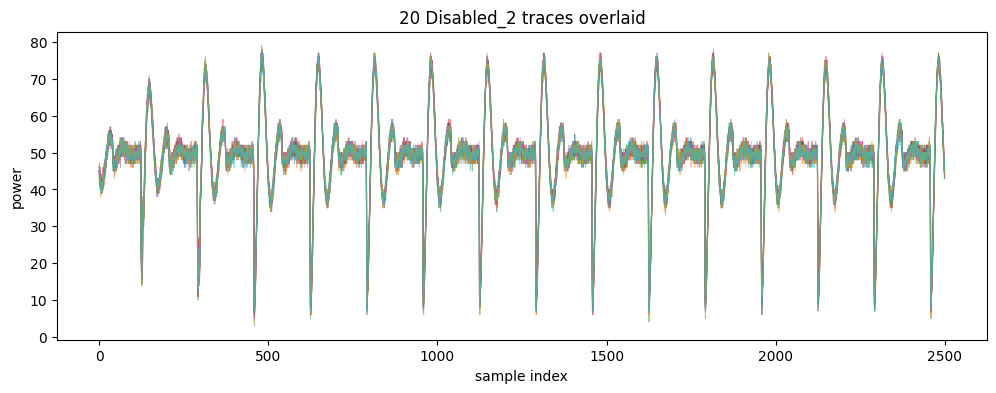

In [3]:
d2 = np.load(f"{DATA}/AES-T800+TrojanDisabled_2.npy")
t2 = np.load(f"{DATA}/AES-T800+TrojanTriggered_2.npy")

os.makedirs("results/figures", exist_ok=True)

plt.figure(figsize=(12,4))
for i in range(20):
  plt.plot(d2[i], alpha=0.5, linewidth=0.7)
plt.title("20 Disabled_2 traces overlaid")
plt.xlabel("sample index"); plt.ylabel("power")
plt.savefig("results/figures/01_alignment.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that incides and power measurements are consistent across all traces.

#### Mean Comparison Plot: Normal vs Triggered
Here, we see if there are any visual changes made by the Trojan trigger, comparing it to the normal data.

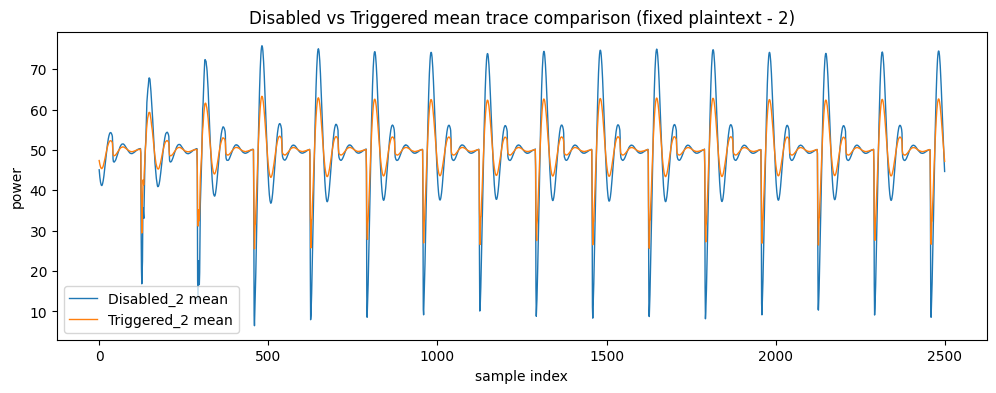

In [4]:
plt.figure(figsize=(12,4))
plt.plot(d2.mean(axis=0), label="Disabled_2 mean", linewidth=1)
plt.plot(t2.mean(axis=0), label="Triggered_2 mean", linewidth=1)
plt.legend()
plt.title("Disabled vs Triggered mean trace comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
plt.savefig("results/figures/02_mean_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that there is a noticable impact on the power output of the circuit when a trojan is active.

#### Difference of Means: Normal vs Triggered
Here, we compare the difference of the mean power of both triggered and normal traces. This highlights the magnitude of the difference between the two signals.

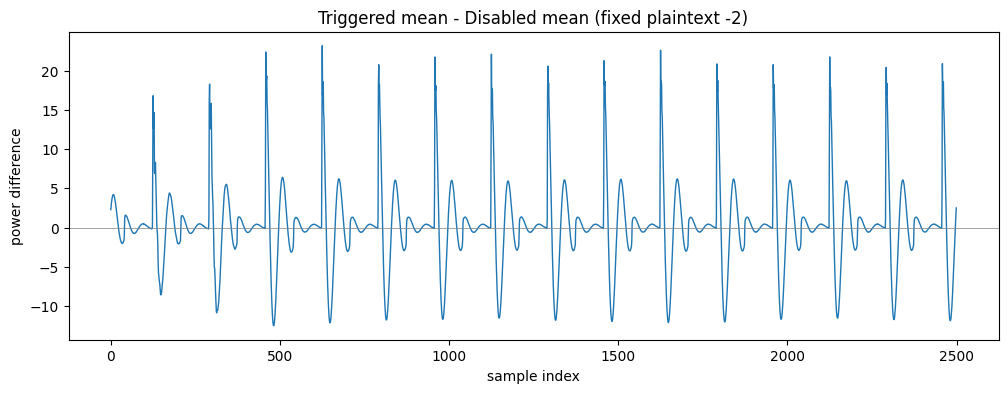

In [5]:
diff = t2.mean(axis=0) - d2.mean(axis=0)
plt.figure(figsize=(12,4))
plt.plot(diff, linewidth=1)
plt.axhline(0, color="gray", linewidth=0.5)
plt.title("Triggered mean - Disabled mean (fixed plaintext -2)")
plt.xlabel("sample index")
plt.ylabel("power difference")
plt.savefig("results/figures/03_diff.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

#### Per-trace Mean Histogram
This plot is the distribution of the average across the entire trace. While separation betwen power averages is trivial, this may not be the case for other trojan variants (T-600 and T-1600, Golabi et. al).

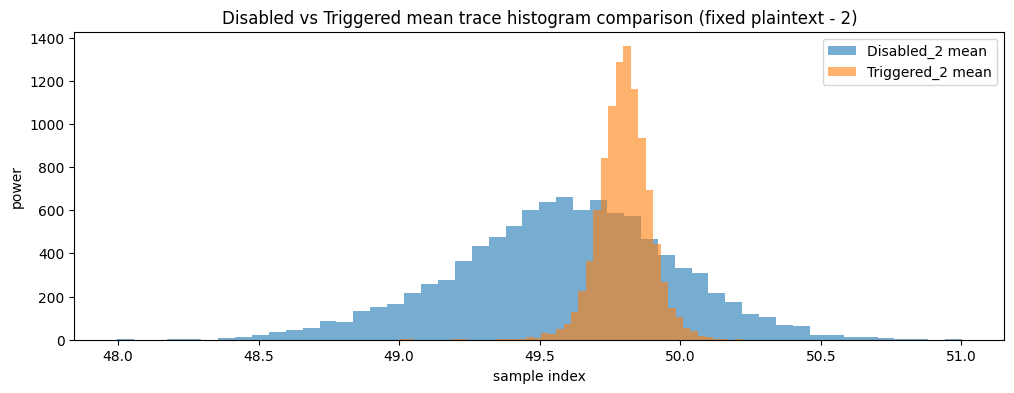

In [16]:
plt.figure(figsize=(12,4))
plt.hist(d2.mean(axis=1), bins=50, alpha=0.6, label = "Disabled_2 mean")
plt.hist(t2.mean(axis=1), bins=50, alpha=0.6, label = "Triggered_2 mean")
plt.legend()
plt.title("Disabled vs Triggered mean trace histogram comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
plt.savefig("results/figures/04_hist.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()